In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

_cwd = Path.cwd().resolve()
if (_cwd / "data" / "HumidityLookup.csv").exists():
    DATA_DIR = _cwd / "data"
elif (_cwd.parent / "data" / "HumidityLookup.csv").exists():
    DATA_DIR = _cwd.parent / "data"
else:
    DATA_DIR = _cwd.parent / "data"

sns.set_theme(style="whitegrid")


In [2]:
df_Hum = pd.read_csv(DATA_DIR / "HumidityLookup.csv")
df_Ph = pd.read_csv(DATA_DIR / "PHRangeLookup.csv")
df_Soil = pd.read_csv(DATA_DIR / "SoilTextureLookup.csv")
df_Var = pd.read_csv(DATA_DIR / "PlantVariety.csv")
df_PlantType = pd.read_csv(DATA_DIR / "PlantTypeLookup.csv")
df_Hard = pd.read_csv(DATA_DIR / "PlantHardinessZoneLookup.csv")
df_Saline = pd.read_csv(DATA_DIR / "SalinityLookup.csv")
df_OrgMat = pd.read_csv(DATA_DIR / "OrganicMatterLookup.csv")
df_plant = pd.read_csv(DATA_DIR / "Plant.csv")


In [3]:
# Unify hardiness zones: aggregate temperature ranges by numeric zone
df_Hard = df_Hard.copy()
df_Hard["UnifiedZone"] = df_Hard["Zone"].astype(str).str.extract(r"(\d+)")
merged_zone_data = (
    df_Hard.dropna(subset=["UnifiedZone"])
    .groupby("UnifiedZone", as_index=False)
    .agg({"TemperatureStartRange": "min", "TemperatureEndRange": "max"})
)
merged_zone_data["UnifiedZone"] = merged_zone_data["UnifiedZone"].astype(float)
df_Hard_new = merged_zone_data


In [4]:
# Join the dataframes
joins = (
    df_plant
    .merge(df_Ph[["PHRangeID", "PHRange", "SoilType"]], on="PHRangeID", how="left")
    .merge(
        df_Hard_new[["UnifiedZone", "TemperatureStartRange", "TemperatureEndRange"]],
        left_on="ZoneID",
        right_on="UnifiedZone",
        how="left",
    )
    .merge(df_PlantType[["PlantTypeID", "PlantType"]], on="PlantTypeID", how="left")
    .merge(df_Soil[["SoilTextureID", "SoilTexture"]], on="SoilTextureID", how="left")
    .merge(df_Hum[["HumidityID", "Classification"]], on="HumidityID", how="left")
    .merge(
        df_OrgMat[["OrganicMatterID", "OrganicMatterContent"]],
        on="OrganicMatterID",
        how="left",
    )
    .merge(
        df_Saline[["SalinityLevelID", "SalinityLevel", "Classification"]],
        on="SalinityLevelID",
        how="left",
        suffixes=("", "_Salinity"),
    )
)
if "PlantVarietyName" not in df_plant.columns:
    result = joins.merge(df_Var[["PlantID", "PlantVarietyName"]], on="PlantID", how="left")
else:
    result = joins

result = result.drop(columns=["PlantDescription"])

print(result.head())


   PlantID PlantName PlantVarietyName  SoilTextureID  PHRangeID  \
0        2   Lettuce        Looseleaf              3          3   
1        2   Lettuce         Oak Leaf              2          3   
2        3    Tomato             Roma              2          4   
3        4     Basil   Basil Genovese              2          3   
4        2   Lettuce        Looseleaf              2          4   

   OrganicMatterID  SalinityLevelID    ZoneID  HumidityID  PlantTypeID  ...  \
0                2                1  9.329198           3            1  ...   
1                3                2  9.889315           3            1  ...   
2                2                1  9.272227           2            2  ...   
3                3                1  9.699248           2            3  ...   
4                1                2  8.982526           3            1  ...   

  SoilType UnifiedZone  TemperatureStartRange  TemperatureEndRange  PlantType  \
0     Clay         NaN                   

In [5]:
# Optional: export joined table
# result.to_csv(DATA_DIR / "Joined_Data.csv", index=False)


In [6]:
final_df = result

In [7]:
final_df.describe()

,PlantID,SoilTextureID,PHRangeID,OrganicMatterID,SalinityLevelID,ZoneID,HumidityID,PlantTypeID,UnifiedZone,TemperatureStartRange,TemperatureEndRange
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,558.000000,558.000000,558.000000
mean,2.839500,2.035000,3.023000,2.097000,1.387500,9.173447,2.160500,1.839500,9.362007,25.215054,34.258065
std,0.801287,0.806288,0.962774,0.800569,0.487301,0.681259,0.805645,0.801287,0.933012,6.997588,8.397105
min,2.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,8.000000,15.000000,22.000000
25%,2.000000,1.000000,2.000000,1.000000,1.000000,8.662448,1.000000,1.000000,8.000000,15.000000,22.000000
50%,3.000000,2.000000,3.000000,2.000000,1.000000,9.203133,2.000000,2.000000,10.000000,30.000000,40.000000
75%,4.000000,3.000000,4.000000,3.000000,2.000000,9.866109,3.000000,3.000000,10.000000,30.000000,40.000000
max,4.000000,3.000000,4.000000,3.000000,2.000000,10.000000,3.000000,3.000000,10.000000,30.000000,40.000000


In [8]:
final_df.isnull().sum()

PlantID                       0
PlantName                     0
PlantVarietyName              0
SoilTextureID                 0
PHRangeID                     0
OrganicMatterID               0
SalinityLevelID               0
ZoneID                        0
HumidityID                    0
PlantTypeID                   0
PHRange                       0
SoilType                      0
UnifiedZone                1442
TemperatureStartRange      1442
TemperatureEndRange        1442
PlantType                     0
SoilTexture                   0
Classification                0
OrganicMatterContent          0
SalinityLevel                 0
Classification_Salinity       0
dtype: int64

In [9]:
# Drop rows with any missing values in the DataFrame
cleaned_df = final_df.dropna()

# Display the number of rows before and after cleaning
print("Rows before cleaning:", final_df.shape[0])
print("Rows after cleaning:", cleaned_df.shape[0])


Rows before cleaning: 2000
Rows after cleaning: 558


In [10]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 558 entries, 9 to 1997
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   PlantID                  558 non-null    int64  
 1   PlantName                558 non-null    object 
 2   PlantVarietyName         558 non-null    object 
 3   SoilTextureID            558 non-null    int64  
 4   PHRangeID                558 non-null    int64  
 5   OrganicMatterID          558 non-null    int64  
 6   SalinityLevelID          558 non-null    int64  
 7   ZoneID                   558 non-null    float64
 8   HumidityID               558 non-null    int64  
 9   PlantTypeID              558 non-null    int64  
 10  PHRange                  558 non-null    object 
 11  SoilType                 558 non-null    object 
 12  UnifiedZone              558 non-null    float64
 13  TemperatureStartRange    558 non-null    float64
 14  TemperatureEndRange      558 n

In [11]:
# Optional: export cleaned table
# cleaned_df.to_csv(DATA_DIR / "cleaned_df.csv", index=False)


In [12]:

cleaned_df['OrganicMatterContent'] = cleaned_df['OrganicMatterContent'].replace({
    'Moderate (2% - 4%)': 'Moderate',
    'Low (1% - 2%)': 'Low',
    'High (4% - 6%)': 'High'
})
#Print the updated DataFrame
cleaned_df

C:\Users\fathi\AppData\Local\Temp\ipykernel_27028\616975971.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df['OrganicMatterContent'] = cleaned_df['OrganicMatterContent'].replace({


,PlantID,PlantName,PlantVarietyName,SoilTextureID,PHRangeID,OrganicMatterID,SalinityLevelID,ZoneID,HumidityID,PlantTypeID,...,SoilType,UnifiedZone,TemperatureStartRange,TemperatureEndRange,PlantType,SoilTexture,Classification,OrganicMatterContent,SalinityLevel,Classification_Salinity
9,3,Tomato,Cherry,1,4,3,1,10.0,2,2,...,Loamy,10.0,30.0,40.0,Fruit,Sandy Soil,Moderate,High,< 2,Non-Saline
11,4,Basil,Basil Genovese,3,3,3,2,10.0,2,3,...,Clay,10.0,30.0,40.0,Herb,Clay Soil,Moderate,High,>= 2,Saline
12,2,Lettuce,Oak Leaf,3,3,2,2,10.0,1,1,...,Clay,10.0,30.0,40.0,Vegetable,Clay Soil,Low,Moderate,>= 2,Saline
20,4,Basil,Sweet,2,4,2,1,8.0,3,3,...,Loamy,8.0,15.0,22.0,Herb,Loamy Soil,High,Moderate,< 2,Non-Saline
26,2,Lettuce,Crisphead,2,3,3,2,8.0,1,1,...,Clay,8.0,15.0,22.0,Vegetable,Loamy Soil,Low,High,>= 2,Saline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1978,4,Basil,Basil Genovese,3,3,3,1,10.0,3,3,...,Clay,10.0,30.0,40.0,Herb,Clay Soil,High,High,< 2,Non-Saline
1985,4,Basil,Basil Genovese,3,2,3,1,10.0,2,3,...,Loamy,10.0,30.0,40.0,Herb,Clay Soil,Moderate,High,< 2,Non-Saline
1990,3,Tomato,Cherry,1,4,3,2,10.0,3,2,...,Loamy,10.0,30.0,40.0,Fruit,Sandy Soil,High,High,>= 2,Saline
1993,4,Basil,Basil Genovese,2,2,2,2,10.0,1,3,...,Loamy,10.0,30.0,40.0,Herb,Loamy Soil,Low,Moderate,>= 2,Saline


In [13]:
cleaned_df['PlantType'].value_counts()

PlantType
Vegetable    224
Herb         178
Fruit        156
Name: count, dtype: int64

In [14]:
# Create a copy of the cleaned_df
cleaned_df_copy4 = cleaned_df.copy()

# Check the copy to confirm it matches the original
cleaned_df_copy4.head()


,PlantID,PlantName,PlantVarietyName,SoilTextureID,PHRangeID,OrganicMatterID,SalinityLevelID,ZoneID,HumidityID,PlantTypeID,...,SoilType,UnifiedZone,TemperatureStartRange,TemperatureEndRange,PlantType,SoilTexture,Classification,OrganicMatterContent,SalinityLevel,Classification_Salinity
9,3,Tomato,Cherry,1,4,3,1,10.0,2,2,...,Loamy,10.0,30.0,40.0,Fruit,Sandy Soil,Moderate,High,< 2,Non-Saline
11,4,Basil,Basil Genovese,3,3,3,2,10.0,2,3,...,Clay,10.0,30.0,40.0,Herb,Clay Soil,Moderate,High,>= 2,Saline
12,2,Lettuce,Oak Leaf,3,3,2,2,10.0,1,1,...,Clay,10.0,30.0,40.0,Vegetable,Clay Soil,Low,Moderate,>= 2,Saline
20,4,Basil,Sweet,2,4,2,1,8.0,3,3,...,Loamy,8.0,15.0,22.0,Herb,Loamy Soil,High,Moderate,< 2,Non-Saline
26,2,Lettuce,Crisphead,2,3,3,2,8.0,1,1,...,Clay,8.0,15.0,22.0,Vegetable,Loamy Soil,Low,High,>= 2,Saline


In [15]:
from sklearn.preprocessing import LabelEncoder

variety_encoder = LabelEncoder()
cleaned_df_copy4["PlantVarietyName_enc"] = variety_encoder.fit_transform(
    cleaned_df_copy4["PlantVarietyName"]
)

cleaned_df_copy4.head()


,PlantID,PlantName,PlantVarietyName,SoilTextureID,PHRangeID,OrganicMatterID,SalinityLevelID,ZoneID,HumidityID,PlantTypeID,...,UnifiedZone,TemperatureStartRange,TemperatureEndRange,PlantType,SoilTexture,Classification,OrganicMatterContent,SalinityLevel,Classification_Salinity,PlantVarietyName_enc
9,3,Tomato,Cherry,1,4,3,1,10.0,2,2,...,10.0,30.0,40.0,Fruit,Sandy Soil,Moderate,High,< 2,Non-Saline,2
11,4,Basil,Basil Genovese,3,3,3,2,10.0,2,3,...,10.0,30.0,40.0,Herb,Clay Soil,Moderate,High,>= 2,Saline,0
12,2,Lettuce,Oak Leaf,3,3,2,2,10.0,1,1,...,10.0,30.0,40.0,Vegetable,Clay Soil,Low,Moderate,>= 2,Saline,5
20,4,Basil,Sweet,2,4,2,1,8.0,3,3,...,8.0,15.0,22.0,Herb,Loamy Soil,High,Moderate,< 2,Non-Saline,8
26,2,Lettuce,Crisphead,2,3,3,2,8.0,1,1,...,8.0,15.0,22.0,Vegetable,Loamy Soil,Low,High,>= 2,Saline,3


In [16]:
variety_mapping = dict(
    zip(variety_encoder.classes_, range(len(variety_encoder.classes_)))
)
print(variety_mapping)


{'Basil Genovese': 0, 'Beefsteak': 1, 'Cherry': 2, 'Crisphead': 3, 'Little Gem': 4, 'Oak Leaf': 5, 'Red Leaf Lettuce': 6, 'Roma': 7, 'Sweet': 8}


In [17]:
cleaned_df_copy4['PHRange']

9       7.1 - 7.5
11      6.6 - 7.0
12      6.6 - 7.0
20      7.1 - 7.5
26      6.6 - 7.0
          ...    
1978    6.6 - 7.0
1985    6.1 - 6.5
1990    7.1 - 7.5
1993    6.1 - 6.5
1997    7.1 - 7.5
Name: PHRange, Length: 558, dtype: object

<>:25: SyntaxWarning: invalid escape sequence '\w'
<>:25: SyntaxWarning: invalid escape sequence '\w'
C:\Users\fathi\AppData\Local\Temp\ipykernel_27028\1292499494.py:25: SyntaxWarning: invalid escape sequence '\w'
  X_encoded.columns = X_encoded.columns.str.replace("[^\w\s]", "", regex=True)


C:\Users\fathi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best params: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 100}
Random Forest Accuracy: 0.87

Classification Report for Random Forest:

                  precision    recall  f1-score   support

  Basil Genovese       1.00      1.00      1.00        18
       Beefsteak       0.55      0.55      0.55        11
          Cherry       0.69      0.69      0.69        16
       Crisphead       1.00      1.00      1.00        20
      Little Gem       1.00      0.62      0.76        13
        Oak Leaf       0.71      1.00      0.83        12
Red Leaf Lettuce       0.00      0.00      0.00         0
            Roma       0.00      0.00      0.00         0
           Sweet       1.00      1.00      1.00        22

       micro avg       0.87      0.87      0.87       112
       macro avg       0.66      0.65      0.65       112
    weighted avg       0.88      0.87      0.86       112



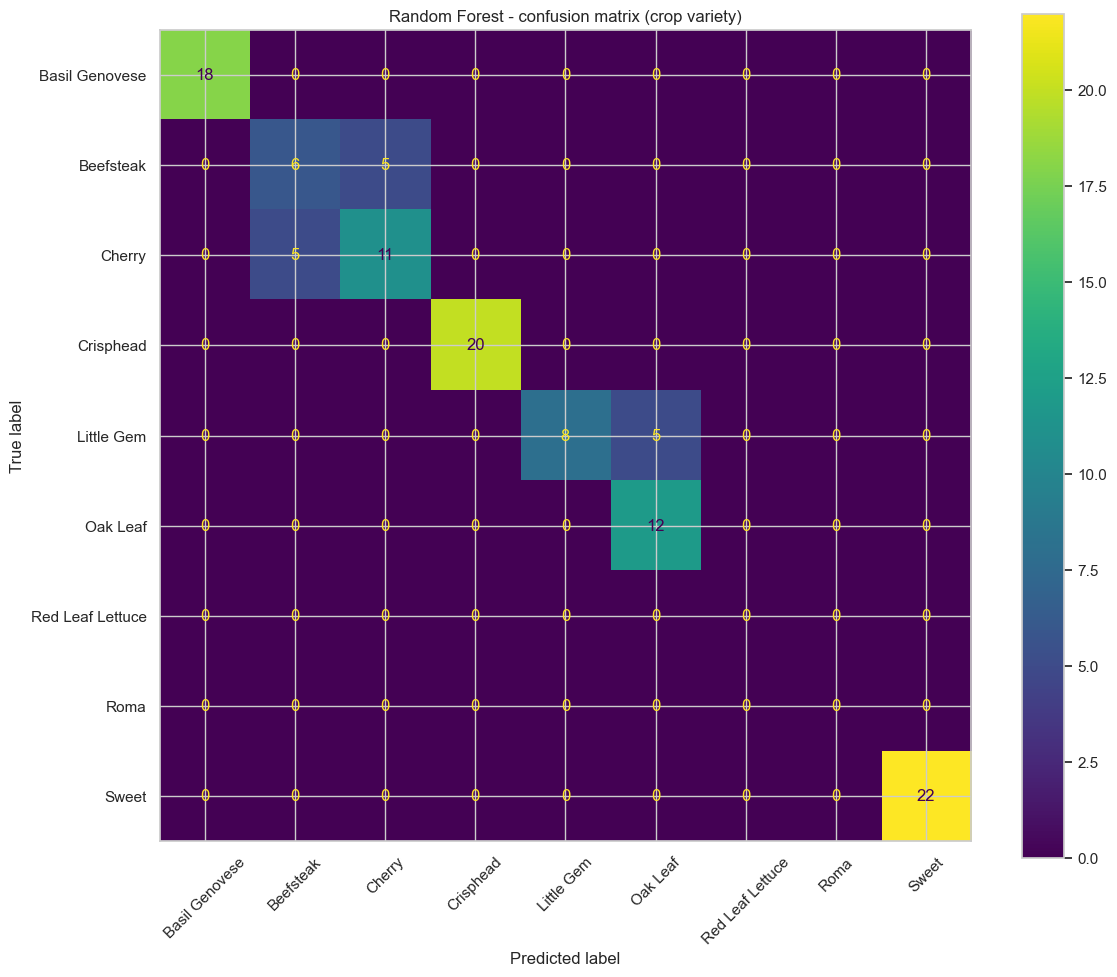

In [18]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Predict crop variety from growing conditions; keep PlantType as a categorical feature
X = cleaned_df_copy4.drop(
    columns=[
        "PlantVarietyName",
        "PlantVarietyName_enc",
        "PlantID",
        "SoilTextureID",
        "PHRangeID",
        "OrganicMatterID",
        "SalinityLevelID",
        "ZoneID",
        "HumidityID",
        "PlantTypeID",
        "PlantName",
        "PHRange",
    ]
)
y = cleaned_df_copy4["PlantVarietyName_enc"]

X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.columns = X_encoded.columns.str.replace("[^\w\s]", "", regex=True)

_strat = y if y.value_counts().min() >= 2 else None
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=_strat
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 15],
    "min_samples_leaf": [1, 2],
}
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)
print("Best params:", grid_search.best_params_)

rf_model = grid_search.best_estimator_
y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.2f}")
print()
print("Classification Report for Random Forest:")
print()
print(
    classification_report(
        y_test,
        y_pred_rf,
        labels=list(range(len(variety_encoder.classes_))),
        target_names=list(variety_encoder.classes_),
        zero_division=0,
    )
)

fig, ax = plt.subplots(figsize=(12, 10))
_labels = list(range(len(variety_encoder.classes_)))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    labels=_labels,
    display_labels=list(variety_encoder.classes_),
    ax=ax,
    xticks_rotation=45,
    colorbar=True,
)
plt.title("Random Forest - confusion matrix (crop variety)")
plt.tight_layout()
plt.show()


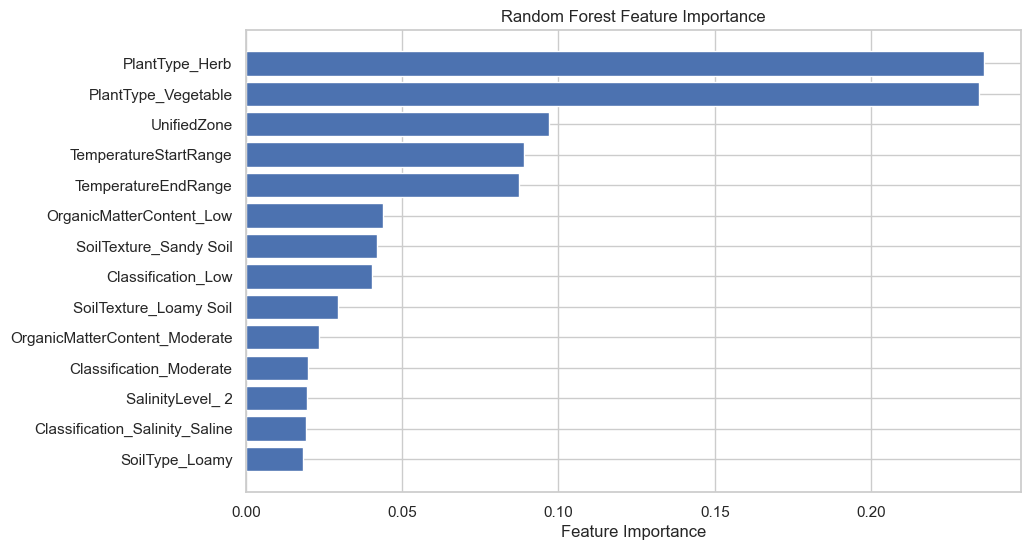

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming `rf_model` is your trained Random Forest model
feature_importances = rf_model.feature_importances_

# Sort feature importances in descending order
sorted_idx = np.argsort(feature_importances)[::-1]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importances)), feature_importances[sorted_idx], align='center')
plt.yticks(range(len(feature_importances)), np.array(X_encoded.columns)[sorted_idx])
plt.gca().invert_yaxis()  # Invert y-axis to display top features at the top
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.show()


In [20]:
cleaned_df.PlantType.value_counts()

PlantType
Vegetable    224
Herb         178
Fruit        156
Name: count, dtype: int64

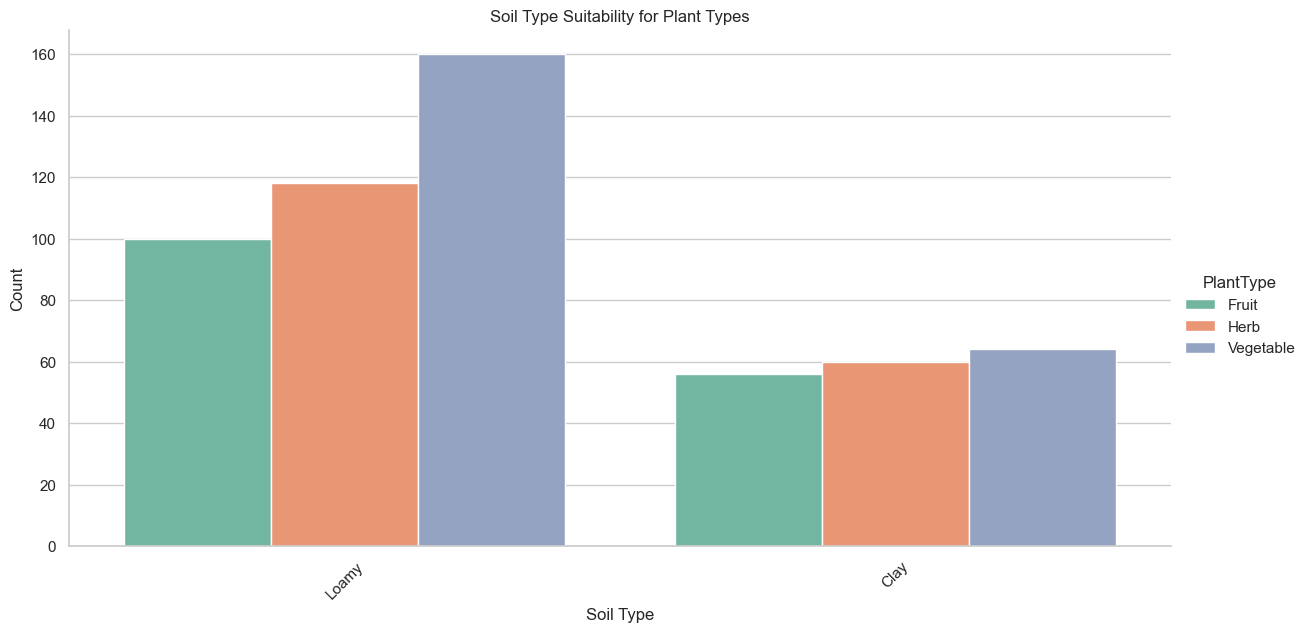

In [21]:
sns.catplot(
    data=cleaned_df, 
    x="SoilType", 
    hue="PlantType", 
    kind="count", 
    height=6, 
    aspect=2, 
    palette="Set2"
)
plt.title('Soil Type Suitability for Plant Types')
plt.ylabel('Count')
plt.xlabel('Soil Type')
plt.xticks(rotation=45)
plt.show()

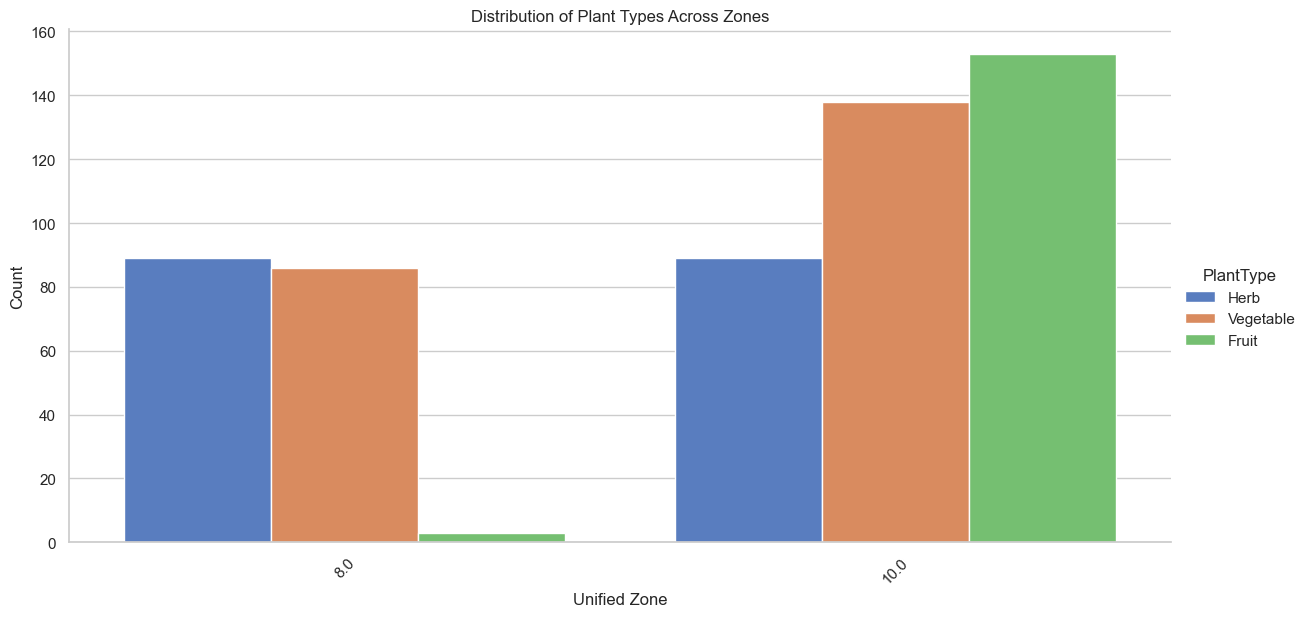

In [22]:
sns.catplot(
    x='UnifiedZone', 
    hue='PlantType', 
    kind='count', 
    data=cleaned_df, 
    height=6, 
    aspect=2, 
    palette='muted'
)
plt.title('Distribution of Plant Types Across Zones')
plt.ylabel('Count')
plt.xlabel('Unified Zone')
plt.xticks(rotation=45)
plt.show()